In [1]:
from topological_insulator import Problem

In [2]:
structure_path = "../../../../data/structures/"
structure_name = "honeycomb.json"

In [3]:
import numpy as np

def set_eigenvalues(problem:Problem, Delta_SOC, t_1, delta):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for label_i in subs:
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        # Diagonal Values
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                # parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.2 * t_1
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1 - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t_1 + delta
            except:
                pass
        # print(parser)   

In [4]:
location = "edge"
N_r = 30

In [5]:
Delta_SOC = -5
cases = {
    0: {"t_1": -1, "delta": 0.632},
    1: {"t_1": -1, "delta": 0.832}
}

In [6]:
results = {}
for n, eigenvalue_dict in cases.items():
    t_1 = eigenvalue_dict["t_1"]
    delta = eigenvalue_dict["delta"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t_1}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    set_eigenvalues(problem, Delta_SOC, t_1, delta)
    problem.setup(
        N_r = N_r,
        N_k = 400,
        location = location,
        BZ = "reduced",
        dangling_bonds=False
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.632
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


In [19]:
import numpy as np
edge_sites = [0, 1, -2, -1]
a = N_r * 8
b = N_r * 16
j_3_2 = [i for i in range(a, b)]
threshold = 0.15

## Case 0

In [20]:
g = results[0].geometry
tb_edge = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

In [21]:
len(tb_edge.sublattice_idxs)

60

In [22]:
LDOS_0, E_0 = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 8.5, 
    E_min = 1.5,
    eta = 0.05
)

LDOS_23, E_23 = invariants.get_local_density_of_states(
    site_idx = 59,
    E_max = 8.5, 
    E_min = 1.5,
    eta = 0.05
)

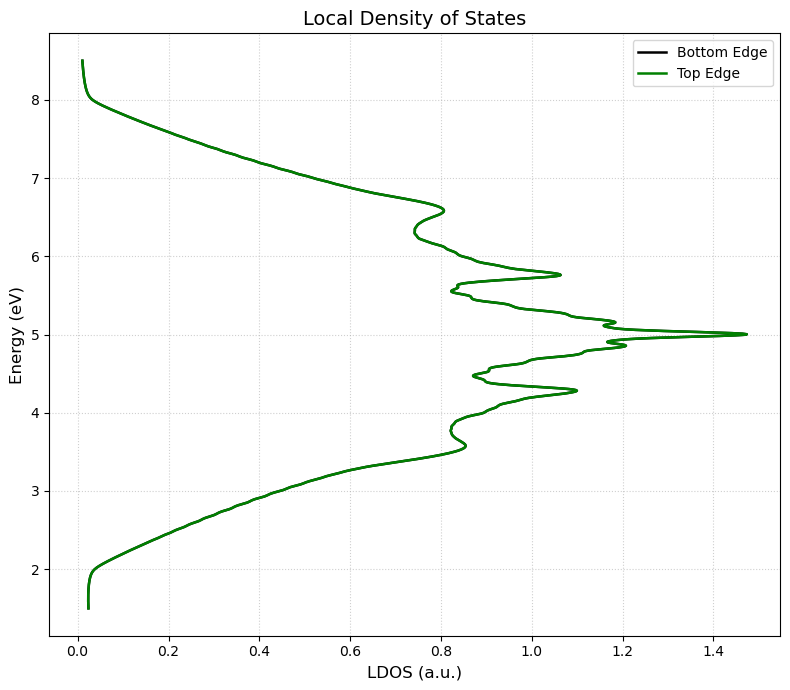

In [23]:
from matplotlib import pyplot as plt
xlabel:str = "LDOS"
figsize: tuple = (8, 7)
fig, ax = plt.subplots(figsize=figsize)
ax.plot(E_0, LDOS_0, color="k", lw=1.8, label=f"Bottom Edge")
ax.plot(E_23, LDOS_23, color="g", lw=1.8, label=f"Top Edge")
ax.set_ylabel("Energy (eV)", fontsize=12)
ax.set_xlabel(f"{xlabel} (a.u.)", fontsize=12)
if xlabel == "LDOS":
    ax.set_title("Local Density of States", fontsize=14)
else:
    ax.set_title("Total Density of States", fontsize=14)
ax.legend(frameon=True)
ax.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

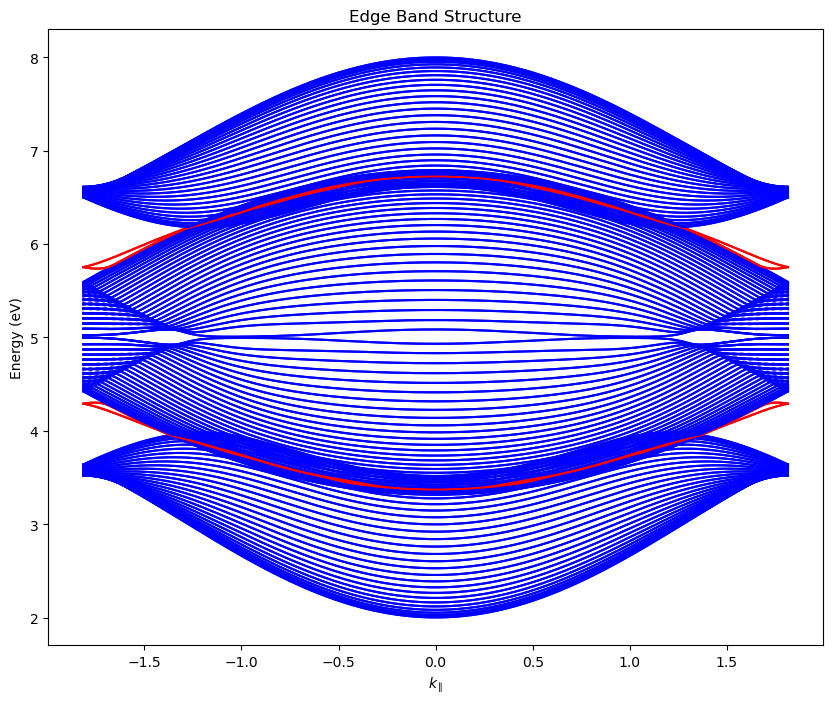

In [24]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=-1.7, threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=1.7, threshold=threshold)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands=edge_bands)

In [13]:
# N_projections = len(tb_edge.coupled_states)
# N_sites = len(tb_edge.sublattice_idxs)
# N_bands = N_sites * N_projections

# Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
# for band in edge_bands:
#     if band in edge_bands_0:
#         k_target = -1.7
#     elif band in edge_bands_1:
#         k_target = 0.0
#     else:
#         k_target = 1.7
#     if band < 100:
#         continue
#     k_idx = np.argmin(np.abs(g.k_edge - k_target))
#     Psi_k = Psi_dict[band][k_idx, :]
#     total_norm = np.sum(np.abs(Psi_k)**2)
#     print(f"band idx: {band}")
#     n_atoms = len(tb_edge.sublattice_idxs)
#     atomic_wavefunctions = {}
#     atom_contributions = np.zeros(n_atoms)
#     for i in range(n_atoms):
#         start = i * N_projections
#         end = start + N_projections
#         orbital_block = Psi_k[start:end]  # Orbitals for atom i
#         atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
#         atomic_wavefunctions[i] = Psi_k[start:end] 

#     from matplotlib import pyplot as plt
#     plt.figure(figsize=(10, 5))
#     plt.bar(range(n_atoms), atom_contributions, color='teal')
#     plt.xlabel("Atom Index")
#     plt.ylabel(f"$|c|^2$")
#     # plt.xlim(0, 10)
#     plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
#     plt.show()

## Case 1

In [14]:
g = results[1].geometry
tb_edge = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]

In [15]:
LDOS_0, E_0 = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 8.5, 
    E_min = 1.5,
    eta = 0.05
)

LDOS_59, E_59 = invariants.get_local_density_of_states(
    site_idx = 59,
    E_max = 8.5, 
    E_min = 1.5,
    eta = 0.05
)

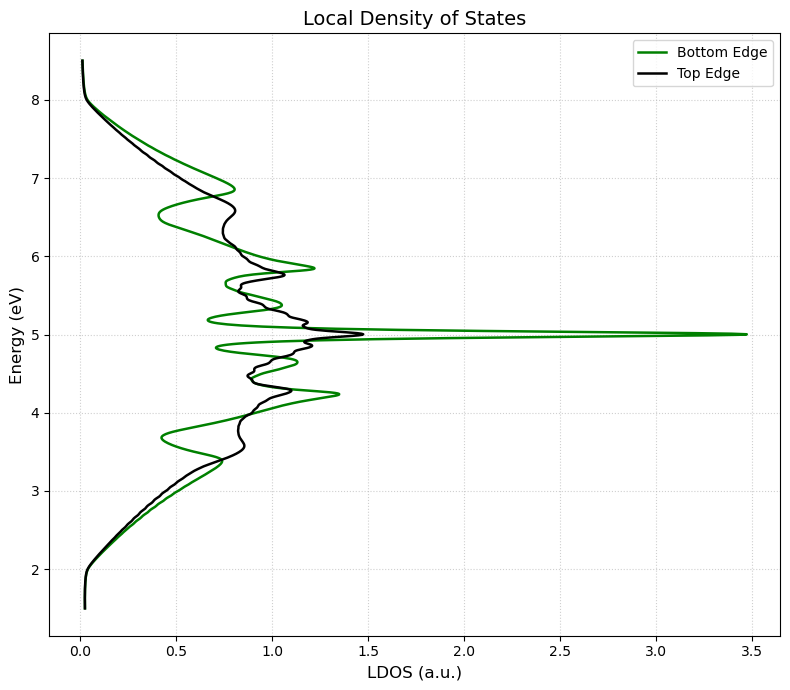

In [16]:
from matplotlib import pyplot as plt
xlabel:str = "LDOS"
figsize: tuple = (8, 7)
fig, ax = plt.subplots(figsize=figsize)
ax.plot(E_0, LDOS_0, color="g", lw=1.8, label=f"Bottom Edge")
ax.plot(E_23, LDOS_23, color="k", lw=1.8, label=f"Top Edge")
ax.set_ylabel("Energy (eV)", fontsize=12)
ax.set_xlabel(f"{xlabel} (a.u.)", fontsize=12)
if xlabel == "LDOS":
    ax.set_title("Local Density of States", fontsize=14)
else:
    ax.set_title("Total Density of States", fontsize=14)
ax.legend(frameon=True)
ax.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

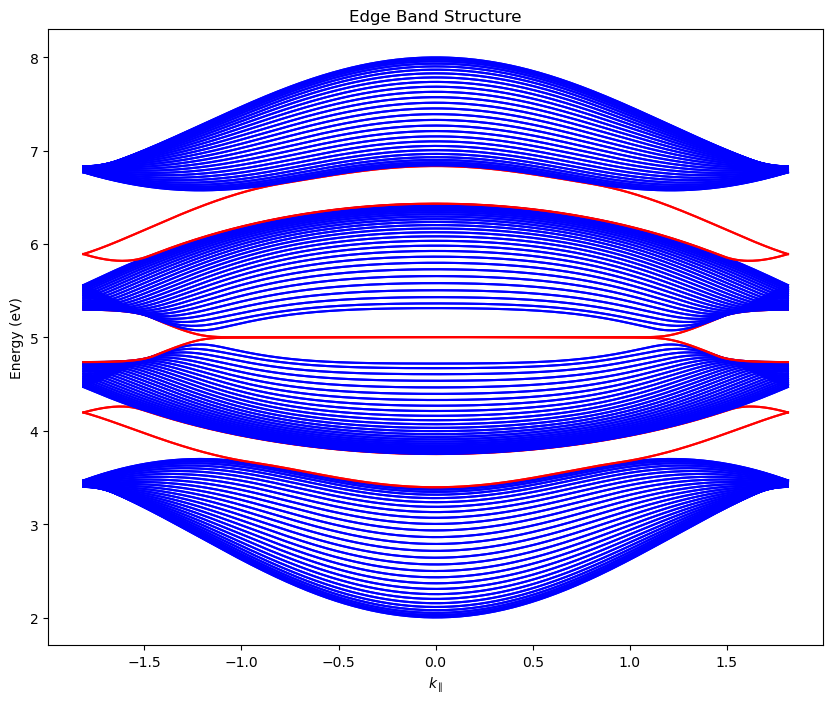

In [17]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=-1.7, threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=1.7, threshold=threshold)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands=edge_bands)

band idx: 298


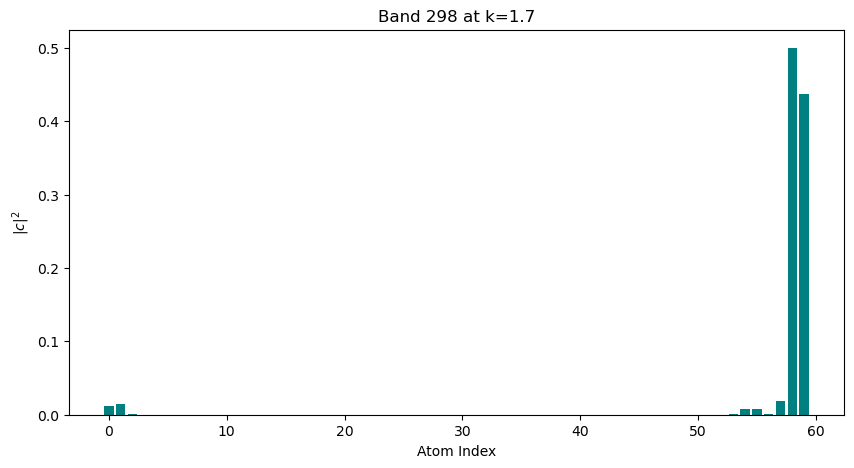

band idx: 299


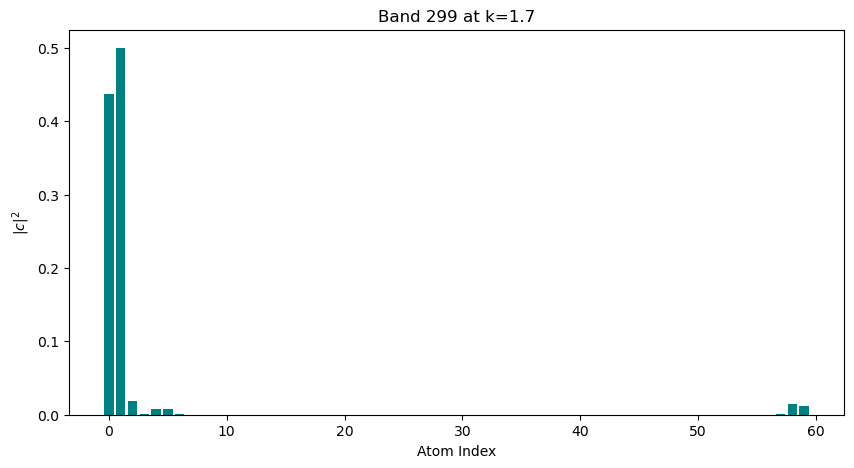

band idx: 300


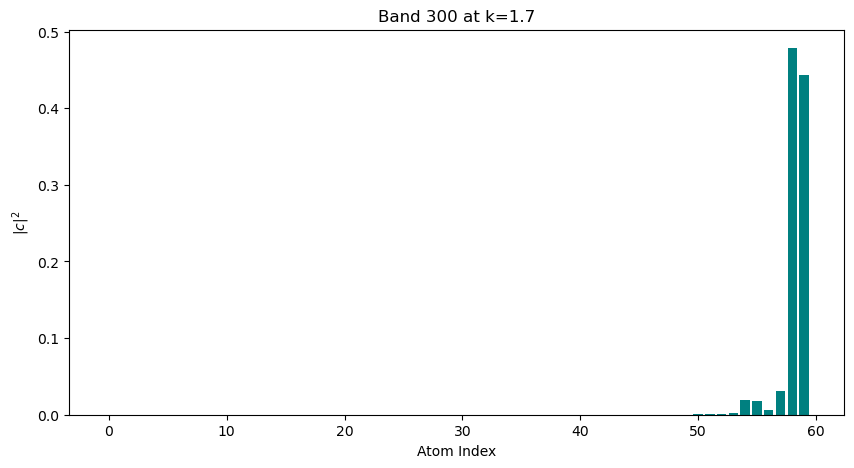

band idx: 301


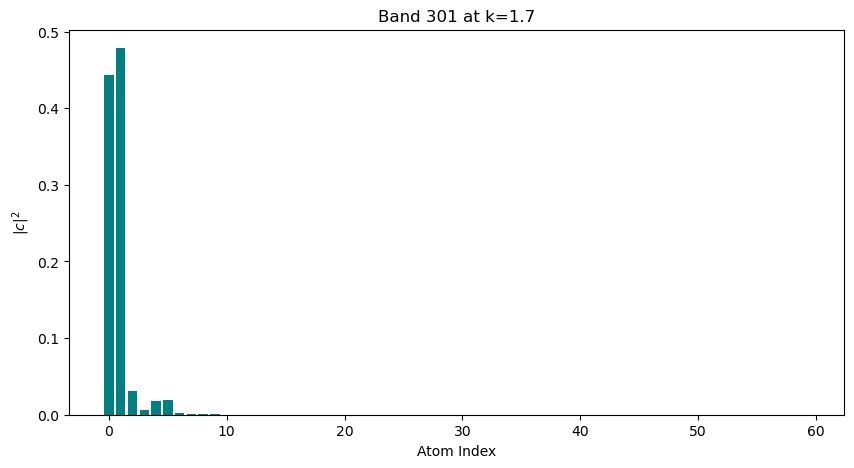

band idx: 358


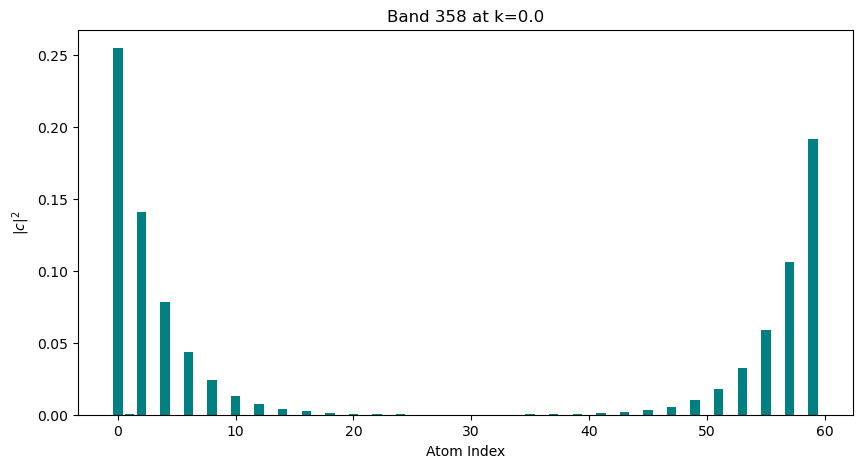

band idx: 359


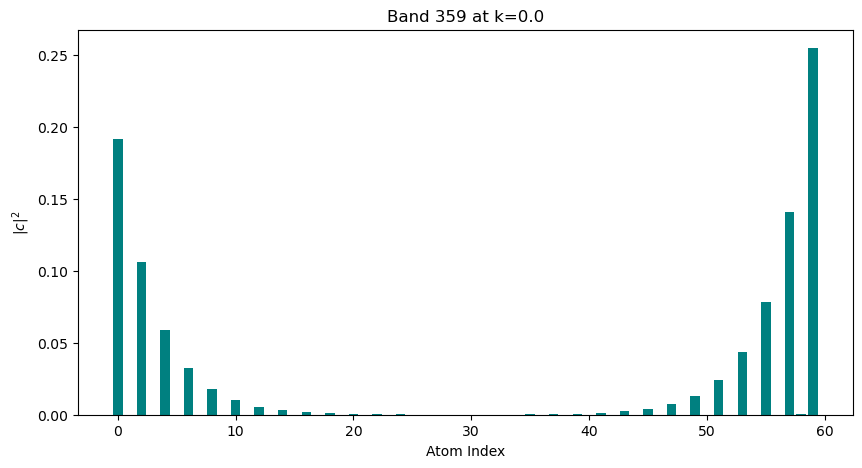

band idx: 360


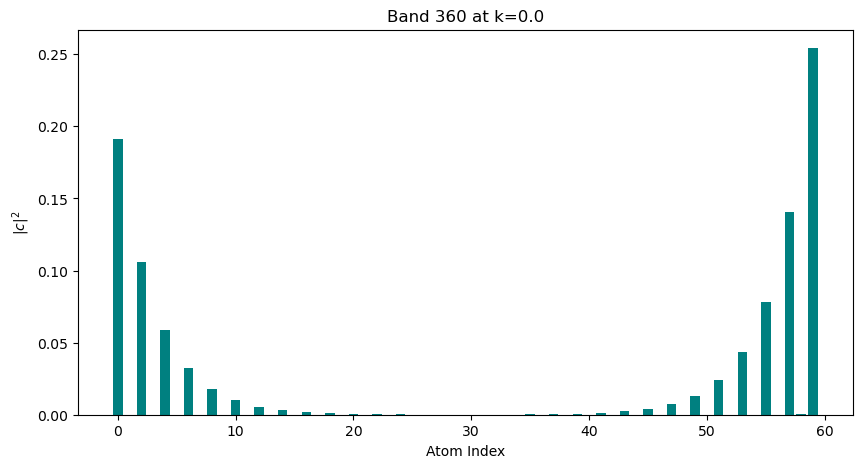

band idx: 361


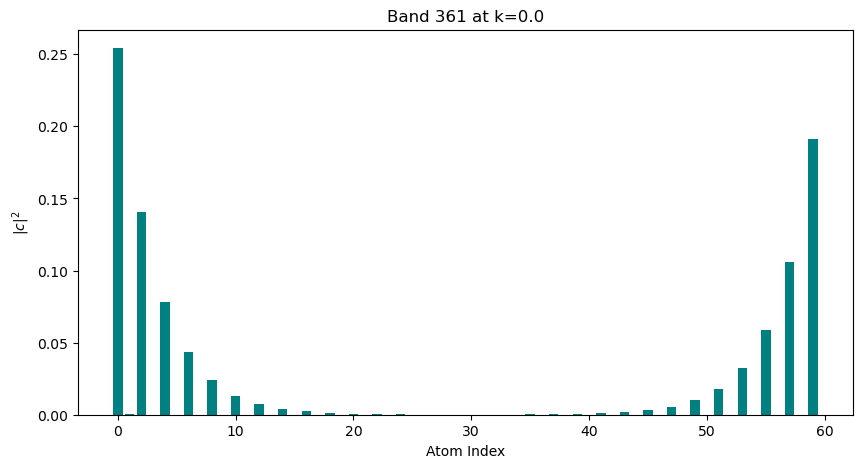

band idx: 418


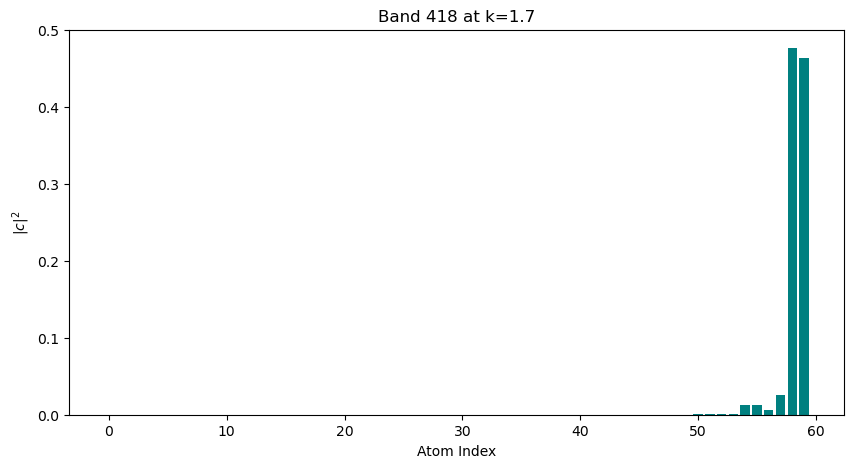

band idx: 419


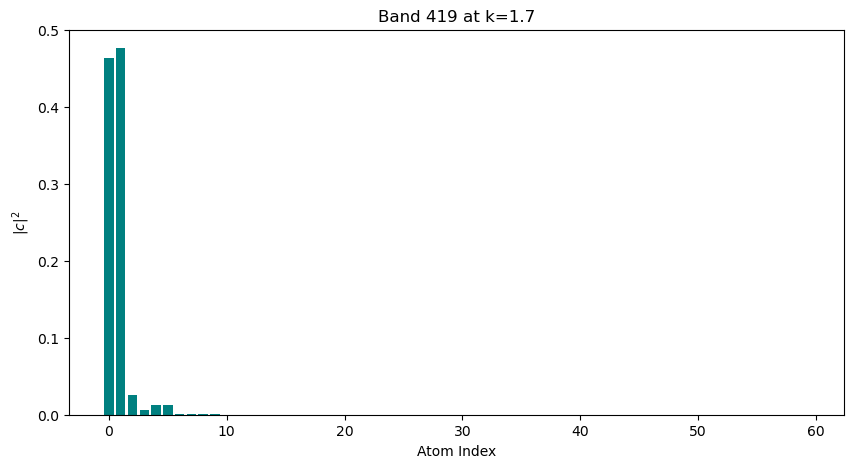

band idx: 420


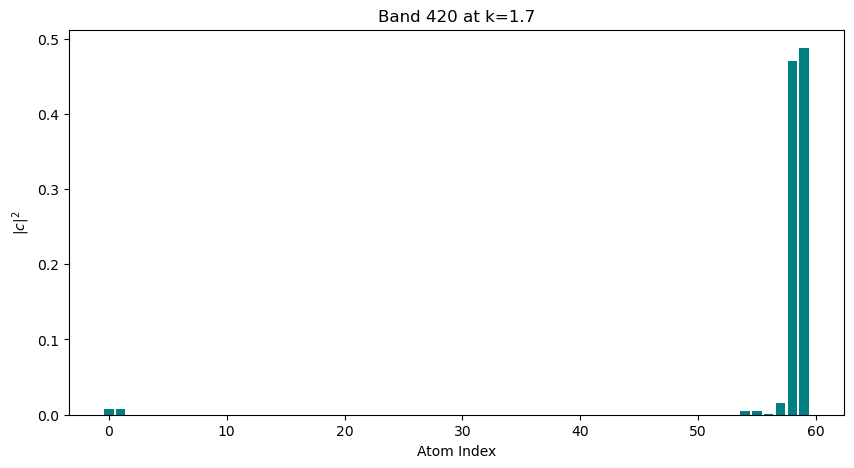

band idx: 421


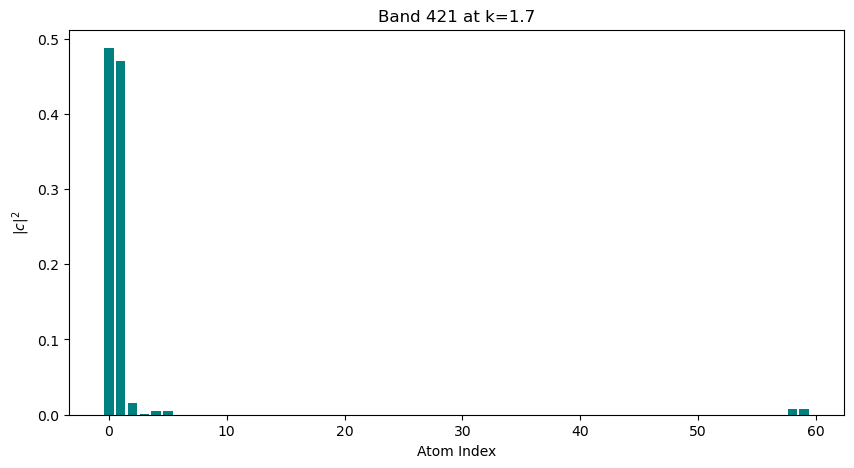

In [18]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    if band in edge_bands_0:
        k_target = -1.7
    elif band in edge_bands_1:
        k_target = 0.0
    else:
        k_target = 1.7
    if band < 100:
        continue
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"band idx: {band}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()